In [1]:
# =========================
# Cell 1: Imports + Config
# =========================
import os
import gc
import json
import math
import tarfile
import random
import warnings
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings("ignore")

print("TF version:", tf.__version__)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")
except Exception as e:
    print("Mixed precision not enabled:", e)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CFG = {
    "extract_root": "/kaggle/working/extracted_parts",
    "save_root": "/kaggle/working/asl_train_100ep",

    "seq_len": 80,    # it was 64
    "batch_size": 16,  # it was 32
    "epochs": 100,

    "init_lr": 1e-4,
    "weight_decay": 1e-5,

    "dropout": 0.30,
    "class_sampling_power": 0.40,  # it was 0.60
    "label_smoothing":0.05,   # new 
    "max_stats_files": 3000,

    "extra_dim": 7
}

os.makedirs(CFG["extract_root"], exist_ok=True)
os.makedirs(CFG["save_root"], exist_ok=True)

print(json.dumps(CFG, indent=2))

2026-04-24 19:19:25.359867: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777058365.576731      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777058365.646353      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777058366.183114      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777058366.183158      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777058366.183161      55 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
Mixed precision enabled.
{
  "extract_root": "/kaggle/working/extracted_parts",
  "save_root": "/kaggle/working/asl_train_100ep",
  "seq_len": 80,
  "batch_size": 16,
  "epochs": 100,
  "init_lr": 0.0001,
  "weight_decay": 1e-05,
  "dropout": 0.3,
  "class_sampling_power": 0.4,
  "label_smoothing": 0.05,
  "max_stats_files": 3000,
  "extra_dim": 7
}


In [2]:
# =========================
# Cell 2: Find archives
# =========================
archive_paths = sorted(glob("/kaggle/input/**/asl_core_part_*.tar.gz", recursive=True))

print("Found archives:", len(archive_paths))
for p in archive_paths:
    print(p)

if len(archive_paths) == 0:
    raise FileNotFoundError("No asl_core_part_*.tar.gz files found under /kaggle/input")

Found archives: 10
/kaggle/input/notebooks/muhammadbarazi/ext-1/asl_core_part_00.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-10/asl_core_part_09.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-2/asl_core_part_01.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-3/asl_core_part_02.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-4/asl_core_part_03.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-5/asl_core_part_04.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-6/asl_core_part_05.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-7/asl_core_part_06.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-8/asl_core_part_07.tar.gz
/kaggle/input/notebooks/muhammadbarazi/ext-9/asl_core_part_08.tar.gz


In [3]:
# =========================
# Cell 3: Extract archives
# =========================
for archive_path in archive_paths:
    base = os.path.basename(archive_path).replace(".tar.gz", "")
    out_dir = os.path.join(CFG["extract_root"], base)

    if not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)
        print(f"Extracting {archive_path} -> {out_dir}")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=out_dir)

print("Extraction done.")

Extracting /kaggle/input/notebooks/muhammadbarazi/ext-1/asl_core_part_00.tar.gz -> /kaggle/working/extracted_parts/asl_core_part_00
Extracting /kaggle/input/notebooks/muhammadbarazi/ext-10/asl_core_part_09.tar.gz -> /kaggle/working/extracted_parts/asl_core_part_09
Extracting /kaggle/input/notebooks/muhammadbarazi/ext-2/asl_core_part_01.tar.gz -> /kaggle/working/extracted_parts/asl_core_part_01
Extracting /kaggle/input/notebooks/muhammadbarazi/ext-3/asl_core_part_02.tar.gz -> /kaggle/working/extracted_parts/asl_core_part_02
Extracting /kaggle/input/notebooks/muhammadbarazi/ext-4/asl_core_part_03.tar.gz -> /kaggle/working/extracted_parts/asl_core_part_03
Extracting /kaggle/input/notebooks/muhammadbarazi/ext-5/asl_core_part_04.tar.gz -> /kaggle/working/extracted_parts/asl_core_part_04
Extracting /kaggle/input/notebooks/muhammadbarazi/ext-6/asl_core_part_05.tar.gz -> /kaggle/working/extracted_parts/asl_core_part_05
Extracting /kaggle/input/notebooks/muhammadbarazi/ext-7/asl_core_part_06.ta

In [4]:
# =========================
# Cell 4: Find manifests
# =========================
train_manifest_paths = sorted(
    glob(os.path.join(CFG["extract_root"], "**", "train_manifest_part_*.csv"), recursive=True)
)
val_manifest_paths = sorted(
    glob(os.path.join(CFG["extract_root"], "**", "val_manifest_part_*.csv"), recursive=True)
)

print("Train manifests:", len(train_manifest_paths))
print("Val manifests  :", len(val_manifest_paths))

for p in train_manifest_paths[:10]:
    print("train:", p)

for p in val_manifest_paths[:10]:
    print("val:", p)

if len(train_manifest_paths) == 0 or len(val_manifest_paths) == 0:
    raise FileNotFoundError("Could not find train/val manifests.")

Train manifests: 10
Val manifests  : 10
train: /kaggle/working/extracted_parts/asl_core_part_00/asl_core_part_00/manifests/train_manifest_part_00.csv
train: /kaggle/working/extracted_parts/asl_core_part_01/asl_core_part_01/manifests/train_manifest_part_01.csv
train: /kaggle/working/extracted_parts/asl_core_part_02/asl_core_part_02/manifests/train_manifest_part_02.csv
train: /kaggle/working/extracted_parts/asl_core_part_03/asl_core_part_03/manifests/train_manifest_part_03.csv
train: /kaggle/working/extracted_parts/asl_core_part_04/asl_core_part_04/manifests/train_manifest_part_04.csv
train: /kaggle/working/extracted_parts/asl_core_part_05/asl_core_part_05/manifests/train_manifest_part_05.csv
train: /kaggle/working/extracted_parts/asl_core_part_06/asl_core_part_06/manifests/train_manifest_part_06.csv
train: /kaggle/working/extracted_parts/asl_core_part_07/asl_core_part_07/manifests/train_manifest_part_07.csv
train: /kaggle/working/extracted_parts/asl_core_part_08/asl_core_part_08/manifes

In [5]:
# =========================
# Cell 5: Merge manifests + fix paths
# =========================
def find_part_root_from_manifest(manifest_path):
    # .../asl_core_part_00/asl_core_part_00/manifests/train_manifest_part_00.csv
    # -> return .../asl_core_part_00/asl_core_part_00
    p = Path(manifest_path).resolve()
    return str(p.parent.parent)

def load_manifest_with_abs_paths(manifest_path):
    df = pd.read_csv(manifest_path)
    part_root = find_part_root_from_manifest(manifest_path)

    df["part_root"] = part_root
    df["abs_feature_path"] = df["feature_path"].astype(str).map(
        lambda x: os.path.join(part_root, x)
    )
    return df

train_parts = [load_manifest_with_abs_paths(p) for p in train_manifest_paths]
val_parts   = [load_manifest_with_abs_paths(p) for p in val_manifest_paths]

train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)
val_df   = pd.concat(val_parts, axis=0).reset_index(drop=True)

PATH_COL = "abs_feature_path"
LABEL_COL = "label_id"

train_df = train_df[train_df[PATH_COL].map(os.path.exists)].reset_index(drop=True)
val_df   = val_df[val_df[PATH_COL].map(os.path.exists)].reset_index(drop=True)

train_df.to_csv("/kaggle/working/train_manifest_merged.csv", index=False)
val_df.to_csv("/kaggle/working/val_manifest_merged.csv", index=False)

print("train_df shape:", train_df.shape)
print("val_df shape  :", val_df.shape)

display(train_df.head())
display(val_df.head())

train_df shape: (40154, 13)
val_df shape  : (10304, 13)


,split,video_path,Video file,Gloss,label_id,feature_path,seq_len,preview_mp4,preview_gif,status,error_msg,part_root,abs_feature_path
0,train,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,15890366051589533-APPLE.mp4,APPLE,67,features/train/15890366051589533-APPLE.npy,59,previews/train/15890366051589533-APPLE.mp4,previews/train/15890366051589533-APPLE.gif,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
1,train,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,35618482303951104-IMPOSSIBLE.mp4,IMPOSSIBLE,1024,features/train/35618482303951104-IMPOSSIBLE.npy,63,previews/train/35618482303951104-IMPOSSIBLE.mp4,previews/train/35618482303951104-IMPOSSIBLE.gif,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
2,train,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,6958143575951994-PARK.mp4,PARK,1421,features/train/6958143575951994-PARK.npy,72,previews/train/6958143575951994-PARK.mp4,previews/train/6958143575951994-PARK.gif,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
3,train,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,8006032738002744-SOCCER 2.mp4,SOCCER,1836,features/train/8006032738002744-SOCCER 2.npy,93,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
4,train,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,37542279833186454-STINK.mp4,STINK,1910,features/train/37542279833186454-STINK.npy,72,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...


,split,video_path,Video file,Gloss,label_id,feature_path,seq_len,preview_mp4,preview_gif,status,error_msg,part_root,abs_feature_path
0,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,1512781787144335-SAIL.mp4,SAIL,1681,features/val/1512781787144335-SAIL.npy,80,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
1,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,5848396359751864-EQUAL.mp4,EQUAL,661,features/val/5848396359751864-EQUAL.npy,70,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
2,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,17988264683482313-PLIERS.mp4,PLIERS,1499,features/val/17988264683482313-PLIERS.npy,60,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
3,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,5864967388246956-DIVE.mp4,DIVE,552,features/val/5864967388246956-DIVE.npy,75,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...
4,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,7916865724879083-BROWN.mp4,BROWN,251,features/val/7916865724879083-BROWN.npy,73,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...


In [6]:
# =========================
# Cell 6: Sanity check
# =========================
sample_path = train_df.iloc[0][PATH_COL]
sample_arr = np.load(sample_path)

print("PATH_COL =", PATH_COL)
print("LABEL_COL =", LABEL_COL)
print("Sample path:", sample_path)
print("Sample shape:", sample_arr.shape)

assert sample_arr.ndim == 2, "Expected feature array shape to be (T, F)"

NUM_CLASSES = int(max(train_df[LABEL_COL].max(), val_df[LABEL_COL].max())) + 1
FEATURE_DIM = sample_arr.shape[1]

print("NUM_CLASSES =", NUM_CLASSES)
print("FEATURE_DIM =", FEATURE_DIM)

PATH_COL = abs_feature_path
LABEL_COL = label_id
Sample path: /kaggle/working/extracted_parts/asl_core_part_00/asl_core_part_00/features/train/15890366051589533-APPLE.npy
Sample shape: (59, 581)
NUM_CLASSES = 2301
FEATURE_DIM = 581


In [7]:
# =========================
# Cell 7: Estimate train mean/std
# =========================
def estimate_feature_stats(df, path_col, max_files=3000):
    n_files = min(len(df), max_files)
    sampled = df.sample(n=n_files, random_state=SEED) if len(df) > n_files else df

    feat_sum = None
    feat_sq_sum = None
    feat_count = 0

    for p in sampled[path_col].tolist():
        x = np.load(p).astype(np.float32)  # (T, F)

        valid_frames = np.any(np.abs(x) > 1e-8, axis=1)
        if valid_frames.any():
            x = x[valid_frames]

        if feat_sum is None:
            feat_sum = np.zeros(x.shape[1], dtype=np.float64)
            feat_sq_sum = np.zeros(x.shape[1], dtype=np.float64)

        feat_sum += x.sum(axis=0)
        feat_sq_sum += (x ** 2).sum(axis=0)
        feat_count += x.shape[0]

    mean = feat_sum / max(feat_count, 1)
    var = feat_sq_sum / max(feat_count, 1) - mean ** 2
    std = np.sqrt(np.maximum(var, 1e-6)).astype(np.float32)
    mean = mean.astype(np.float32)

    return mean, std

train_mean, train_std = estimate_feature_stats(
    train_df,
    PATH_COL,
    max_files=CFG["max_stats_files"]
)

np.savez("/kaggle/working/train_stats.npz", mean=train_mean, std=train_std)

print("train_mean shape:", train_mean.shape)
print("train_std shape :", train_std.shape)

train_mean shape: (581,)
train_std shape : (581,)


In [8]:
# =========================
# Cell 8: Preprocessing functions
# =========================
SEQ_LEN = CFG["seq_len"]

def temporal_resample(x, seq_len=64, training=False):
    T = x.shape[0]

    if T == seq_len:
        return x.astype(np.float32)

    if T <= 1:
        return np.repeat(x, seq_len, axis=0).astype(np.float32)

    idx = np.linspace(0, T - 1, seq_len)

    if training:
        jitter = np.random.uniform(-0.35, 0.35, size=seq_len)
        idx = np.clip(idx + jitter, 0, T - 1)
        idx = np.sort(idx)

    idx = np.rint(idx).astype(np.int32)
    x = x[idx]
    return x.astype(np.float32)

def random_time_mask(x, max_ratio=0.12):
    if np.random.rand() > 0.35:
        return x
    T = x.shape[0]
    L = max(1, int(T * np.random.uniform(0.04, max_ratio)))
    start = np.random.randint(0, max(1, T - L + 1))
    if start > 0:
        x[start:start+L] = x[start-1:start]
    else:
        x[start:start+L] = 0.0
    return x

def random_frame_dropout(x, drop_prob=0.03):
    mask = np.random.rand(x.shape[0]) < drop_prob
    if mask.any():
        x[mask] = 0.0
    return x

def random_gaussian_noise(x, sigma=0.008):
    return x + np.random.normal(0, sigma, size=x.shape).astype(np.float32)

def random_feature_augment(x):
    x = x.copy()
    x = random_time_mask(x)
    x = random_frame_dropout(x, drop_prob=0.03)
    if np.random.rand() < 0.5:
        x = random_gaussian_noise(x, sigma=0.008)
    return x.astype(np.float32)

def standardize_features(x, mean, std):
    return ((x - mean) / (std + 1e-6)).astype(np.float32)

def preprocess_one(path, training=False):
    x = np.load(path).astype(np.float32)

    x = temporal_resample(x, seq_len=SEQ_LEN, training=training)

    if training:
        x = random_feature_augment(x)

    x = standardize_features(x, train_mean, train_std)
    return x

In [9]:
# =========================
# Cell 9: Sequence loader
# =========================
class ASLSequence(tf.keras.utils.Sequence):
    def __init__(self, df, path_col, label_col, batch_size=32, training=False, class_sampling_power=0.0):
        self.df = df.reset_index(drop=True).copy()
        self.path_col = path_col
        self.label_col = label_col
        self.batch_size = batch_size
        self.training = training
        self.class_sampling_power = class_sampling_power

        self.labels = self.df[self.label_col].astype(int).values
        self.paths = self.df[self.path_col].astype(str).values
        self.indices = np.arange(len(self.df))

        if self.training and self.class_sampling_power > 0:
            counts = self.df[self.label_col].value_counts().sort_index()
            self.classes = counts.index.values
            inv = (1.0 / counts.values.astype(np.float32)) ** self.class_sampling_power
            self.class_probs = inv / inv.sum()

            self.class_to_indices = {
                c: self.df.index[self.df[self.label_col] == c].tolist()
                for c in self.classes
            }

        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def on_epoch_end(self):
        if not self.training:
            self.indices = np.arange(len(self.df))

    def _sample_training_indices(self):
        chosen = []
        for _ in range(self.batch_size):
            cls = np.random.choice(self.classes, p=self.class_probs)
            idx = np.random.choice(self.class_to_indices[cls])
            chosen.append(idx)
        return np.array(chosen, dtype=np.int32)

    def __getitem__(self, idx):
        if self.training and self.class_sampling_power > 0:
            batch_idx = self._sample_training_indices()
        else:
            start = idx * self.batch_size
            end = min((idx + 1) * self.batch_size, len(self.df))
            batch_idx = self.indices[start:end]

        X = np.zeros((len(batch_idx), SEQ_LEN, FEATURE_DIM), dtype=np.float32)
        y = np.zeros((len(batch_idx),), dtype=np.int32)

        for i, j in enumerate(batch_idx):
            p = self.paths[j]
            label = self.labels[j]
            try:
                X[i] = preprocess_one(p, training=self.training)
                y[i] = label
            except Exception as e:
                print(f"Warning: failed loading {p} -> {e}")
                X[i] = np.zeros((SEQ_LEN, FEATURE_DIM), dtype=np.float32)
                y[i] = label

        return X, y

train_seq = ASLSequence(
    train_df, PATH_COL, LABEL_COL,
    batch_size=CFG["batch_size"],
    training=True,
    class_sampling_power=CFG["class_sampling_power"]
)

val_seq = ASLSequence(
    val_df, PATH_COL, LABEL_COL,
    batch_size=CFG["batch_size"],
    training=False,
    class_sampling_power=0.0
)

print("train steps:", len(train_seq))
print("val steps  :", len(val_seq))

train steps: 2510
val steps  : 644


In [10]:
# =========================
# Cell 10: Model
# =========================
class AttentionPooling1D(layers.Layer):
    def __init__(self, hidden_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.d1 = layers.Dense(hidden_dim, activation="tanh")
        self.d2 = layers.Dense(1)

    def call(self, x):
        a = self.d2(self.d1(x))   # (B, T, 1)
        a = tf.nn.softmax(a, axis=1)
        out = tf.reduce_sum(x * a, axis=1)
        return out

def temporal_res_block(x, filters, kernel_size=5, dilation=1, drop_rate=0.2, name="tblock"):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same", name=f"{name}_proj")(shortcut)

    y = layers.Conv1D(filters, kernel_size, padding="same", dilation_rate=dilation, use_bias=False, name=f"{name}_conv1")(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)
    y = layers.Activation("swish", name=f"{name}_act1")(y)
    y = layers.SpatialDropout1D(drop_rate, name=f"{name}_drop1")(y)

    y = layers.Conv1D(filters, kernel_size, padding="same", dilation_rate=dilation, use_bias=False, name=f"{name}_conv2")(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)

    y = layers.Add(name=f"{name}_add")([shortcut, y])
    y = layers.Activation("swish", name=f"{name}_act2")(y)
    return y

def build_model(seq_len, feature_dim, num_classes):
    inp = layers.Input(shape=(seq_len, feature_dim), name="input_seq")

    x = layers.LayerNormalization(name="input_ln")(inp)

    x = temporal_res_block(x, filters=128, kernel_size=5, dilation=1, drop_rate=0.15, name="block1")
    x = temporal_res_block(x, filters=128, kernel_size=5, dilation=2, drop_rate=0.15, name="block2")
    x = temporal_res_block(x, filters=160, kernel_size=3, dilation=4, drop_rate=0.15, name="block3")

    x = layers.Bidirectional(
        layers.LSTM(192, return_sequences=True, dropout=0.15),
        name="bilstm_1"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(192, return_sequences=True, dropout=0.15),
        name="bilstm_2"
    )(x)

    attn = AttentionPooling1D(hidden_dim=192, name="attn_pool")(x)
    gmp  = layers.GlobalMaxPooling1D(name="gmp")(x)
    gap  = layers.GlobalAveragePooling1D(name="gap")(x)

    h = layers.Concatenate(name="head_concat")([attn, gmp, gap])
    h = layers.Dense(384, activation="swish", name="head_fc1")(h)
    h = layers.Dropout(0.35, name="head_drop1")(h)
    h = layers.Dense(256, activation="swish", name="head_fc2")(h)
    h = layers.Dropout(0.25, name="head_drop2")(h)

    out = layers.Dense(num_classes, activation="softmax", dtype="float32", name="classifier")(h)

    model = models.Model(inp, out, name="ASLCitizen_ConvBiLSTMAttn")
    return model

model = build_model(SEQ_LEN, FEATURE_DIM, NUM_CLASSES)
model.summary()

I0000 00:00:1777058501.104559      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777058501.110831      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ASLCitizen_ConvBiLSTMAttn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 80, 581)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_ln            │ (None, 80, 581)   │      1,162 │ input_seq[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 80, 128)   │    371,840 │ input_ln[0][0]    │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 80, 128)   │        512 │ block1_conv1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_act1         │ (None, 80, 128)   │          0 │ block1_bn1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_drop1        │ (None, 80, 128)   │          0 │ block1_act1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 80, 128)   │     81,920 │ block1_drop1[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_proj         │ (None, 80, 128)   │     74,496 │ input_ln[0][0]    │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 80, 128)   │        512 │ block1_conv2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 80, 128)   │          0 │ block1_proj[0][0… │
│                     │                   │            │ block1_bn2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_act2         │ (None, 80, 128)   │          0 │ block1_add[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 80, 128)   │     81,920 │ block1_act2[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn1          │ (None, 80, 128)   │        512 │ block2_conv1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_act1         │ (None, 80, 128)   │          0 │ block2_bn1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_drop1        │ (None, 80, 128)   │          0 │ block2_act1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 80, 128)   │     81,920 │ block2_drop1[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 80, 128)   │        512 │ block2_conv2[0][

 Total params: 3,490,728 (13.32 MB)

 Trainable params: 3,489,064 (13.31 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [11]:
# =========================
# Custom sparse loss with label smoothing
# =========================
class SparseLabelSmoothingCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, num_classes, label_smoothing=0.0, from_logits=False, name="sparse_ls_ce"):
        super().__init__(name=name)
        self.num_classes = num_classes
        self.label_smoothing = label_smoothing
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes)
        loss = tf.keras.losses.categorical_crossentropy(
            y_true_oh,
            y_pred,
            from_logits=self.from_logits,
            label_smoothing=self.label_smoothing,
        )
        return tf.reduce_mean(loss)

In [12]:
# =========================
# Cell 11: Compile
# =========================
steps_per_epoch = len(train_seq)
total_steps = max(1, steps_per_epoch * CFG["epochs"])

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=CFG["init_lr"],
    decay_steps=total_steps,
    alpha=0.10
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=CFG["weight_decay"],
    clipnorm=1.0
)

loss_fn = SparseLabelSmoothingCrossEntropy(
    num_classes=NUM_CLASSES,
    label_smoothing=CFG["label_smoothing"],
    from_logits=False
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ]
)

In [13]:
# =========================
# Cell 12: Callbacks
# =========================
ckpt_path = os.path.join(CFG["save_root"], "best_asl_model.keras")

cb = [
    callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_top1",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_top1",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.CSVLogger(os.path.join(CFG["save_root"], "train_log.csv"), append=False)
]

In [14]:
# =========================
# Cell 13: Train
# =========================
history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=CFG["epochs"],
    callbacks=cb,
    verbose=1
)

Epoch 1/100


I0000 00:00:1777058546.597682     120 cuda_dnn.cc:529] Loaded cuDNN version 91002


2509/2510 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.6815 - top1: 8.0254e-04 - top5: 0.0035
Epoch 1: val_top1 improved from -inf to 0.00223, saving model to /kaggle/working/asl_train_100ep/best_asl_model.keras
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 136s 47ms/step - loss: 7.6814 - top1: 8.0323e-04 - top5: 0.0035 - val_loss: 7.2188 - val_top1: 0.0022 - val_top5: 0.0104
Epoch 2/100
2509/2510 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.0067 - top1: 0.0036 - top5: 0.0178
Epoch 2: val_top1 improved from 0.00223 to 0.00912, saving model to /kaggle/working/asl_train_100ep/best_asl_model.keras
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 119s 47ms/step - loss: 7.0066 - top1: 0.0036 - top5: 0.0178 - val_loss: 6.5410 - val_top1: 0.0091 - val_top5: 0.0411
Epoch 3/100
2509/2510 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 6.3660 - top1: 0.0136 - top5: 0.0504
Epoch 3: val_top1 improved from 0.00912 to 0.02116, saving model to /kaggle/working/asl_train_100ep/best_asl_model.keras
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 117s 46ms/step

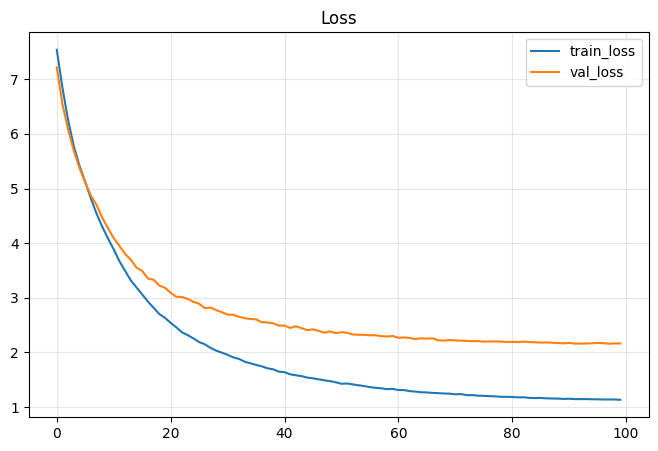

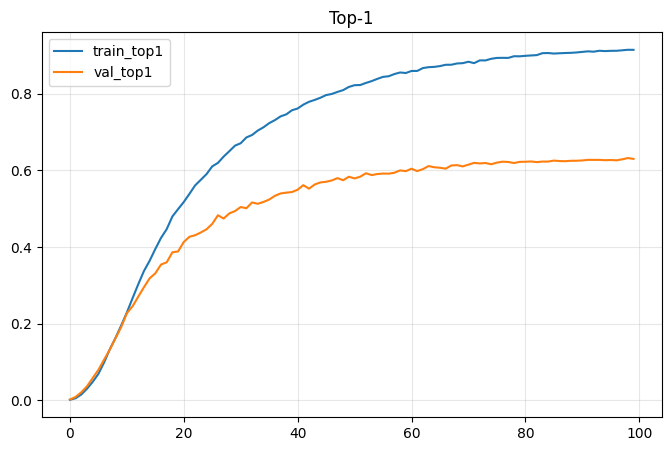

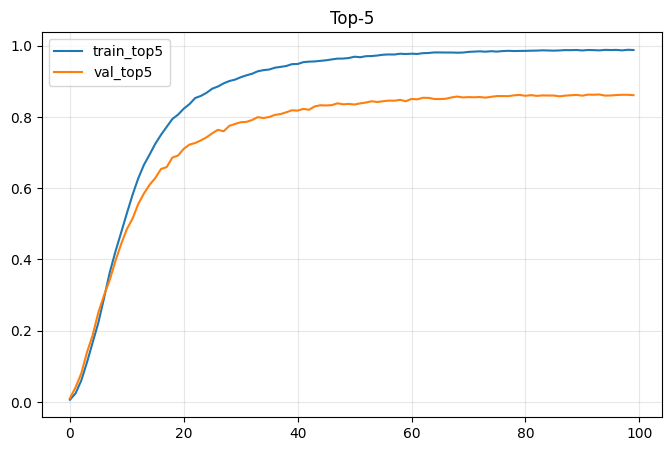

In [15]:
# =========================
# Cell 14: Plot curves
# =========================
def plot_history(history):
    h = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(h["loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.legend()
    plt.title("Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(h["top1"], label="train_top1")
    plt.plot(h["val_top1"], label="val_top1")
    plt.legend()
    plt.title("Top-1")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(h["top5"], label="train_top5")
    plt.plot(h["val_top5"], label="val_top5")
    plt.legend()
    plt.title("Top-5")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_history(history)

In [18]:
# =========================
# Cell 15: Ranking metrics
# =========================
def predict_dataset(model, seq_obj):
    preds = model.predict(seq_obj, verbose=1)
    y_true = seq_obj.df[seq_obj.label_col].astype(int).values
    return preds, y_true

def ranking_metrics(preds, y_true, ks=(1, 5, 10)):
    order = np.argsort(-preds, axis=1)

    results = {}
    for k in ks:
        hits = 0
        for i in range(len(y_true)):
            if y_true[i] in order[i, :k]:
                hits += 1
        results[f"Rec@{k}"] = hits / len(y_true)

    rr = []
    for i in range(len(y_true)):
        rank_pos = np.where(order[i] == y_true[i])[0][0] + 1
        rr.append(1.0 / rank_pos)
    results["MRR"] = float(np.mean(rr))
    return results

best_model = tf.keras.models.load_model(
    ckpt_path,
    custom_objects={"AttentionPooling1D": AttentionPooling1D},
    compile=False
)

val_preds, val_true = predict_dataset(best_model, val_seq)
val_metrics = ranking_metrics(val_preds, val_true, ks=(1, 5, 10))

print("VAL metrics:", val_metrics)

644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step
VAL metrics: {'Rec@1': 0.6319875776397516, 'Rec@5': 0.8622864906832298, 'Rec@10': 0.9078027950310559, 'MRR': 0.7336439014038718}


Val Top-1: 0.6319875776397516
              precision    recall  f1-score   support

           0     0.4000    0.6667    0.5000         3
           1     0.6667    0.5000    0.5714         4
           2     0.2500    0.2500    0.2500         4
           3     0.8333    1.0000    0.9091         5
           4     0.5000    0.2500    0.3333         4
           5     1.0000    0.6364    0.7778        11
           6     0.7500    0.7500    0.7500         4
           7     0.7500    0.7500    0.7500         4
           8     1.0000    0.6000    0.7500         5
           9     0.6000    0.6000    0.6000         5
          10     0.5000    0.7500    0.6000         4
          11     1.0000    1.0000    1.0000         4
          12     1.0000    0.7500    0.8571         4
          13     1.0000    1.0000    1.0000         4
          14     1.0000    0.7500    0.8571         4
          15     0.5000    0.5000    0.5000         4
          16     0.6667    0.5000    0.5714        

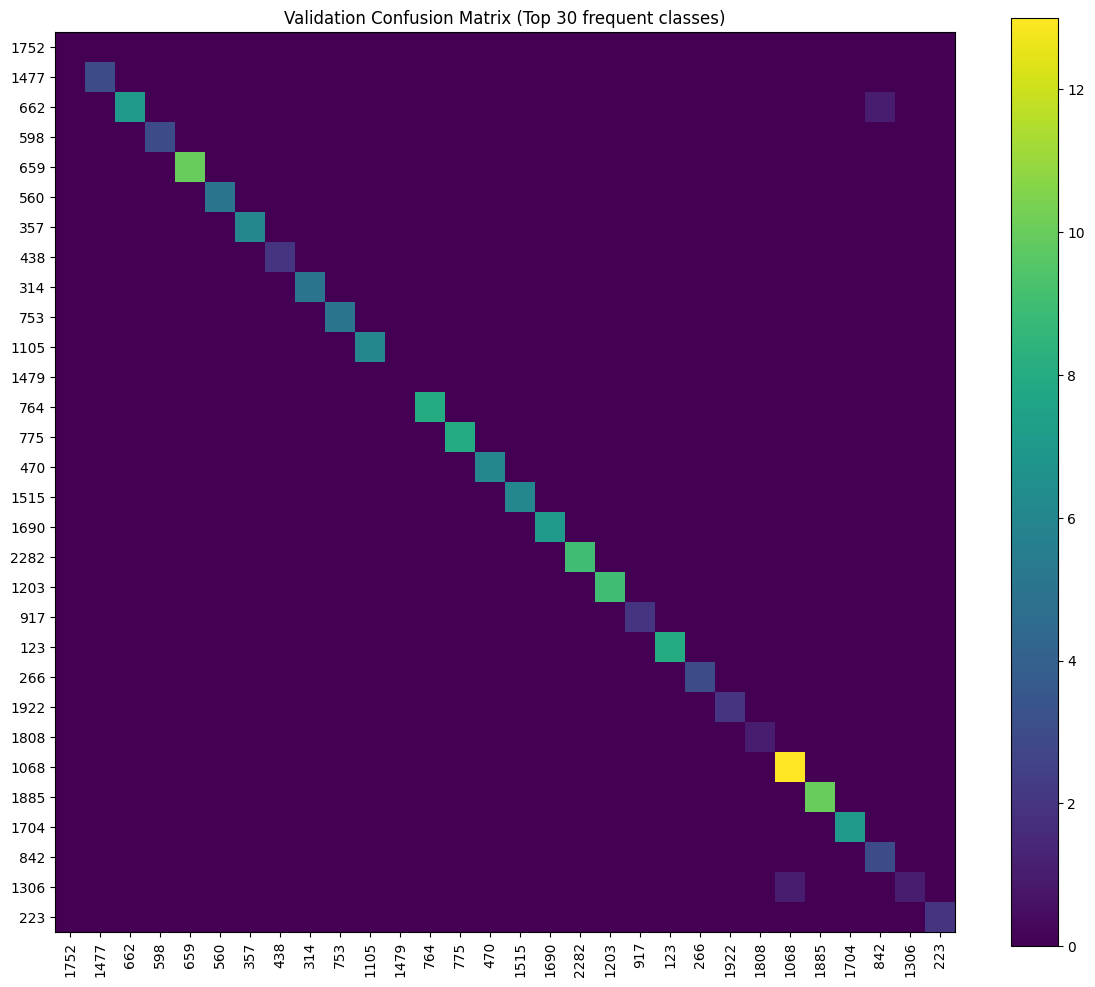

In [19]:
# =========================
# Cell 16: Confusion matrix + report
# =========================
y_pred_val = val_preds.argmax(axis=1)
val_top1 = (y_pred_val == val_true).mean()

print("Val Top-1:", val_top1)
print(classification_report(val_true, y_pred_val, digits=4, zero_division=0))

TOP_N_CLASSES = 30
top_classes = train_df[LABEL_COL].value_counts().head(TOP_N_CLASSES).index.tolist()

mask = np.isin(val_true, top_classes)
cm = confusion_matrix(val_true[mask], y_pred_val[mask], labels=top_classes)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Validation Confusion Matrix (Top {TOP_N_CLASSES} frequent classes)")
plt.colorbar()
plt.xticks(range(len(top_classes)), top_classes, rotation=90)
plt.yticks(range(len(top_classes)), top_classes)
plt.tight_layout()
plt.show()

In [20]:
# =========================
# Cell 17: Save outputs
# =========================
pd.DataFrame(history.history).to_csv(
    os.path.join(CFG["save_root"], "history_full.csv"),
    index=False
)

val_pred_df = val_df.copy()
val_pred_df["pred_label_id"] = y_pred_val
val_pred_df["true_label_id"] = val_true
val_pred_df.to_csv(
    os.path.join(CFG["save_root"], "val_predictions.csv"),
    index=False
)

with open(os.path.join(CFG["save_root"], "val_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, ensure_ascii=False, indent=2)

print("Saved:")
print(os.path.join(CFG["save_root"], "best_asl_model.keras"))
print(os.path.join(CFG["save_root"], "history_full.csv"))
print(os.path.join(CFG["save_root"], "val_predictions.csv"))
print(os.path.join(CFG["save_root"], "val_metrics.json"))

Saved:
/kaggle/working/asl_train_100ep/best_asl_model.keras
/kaggle/working/asl_train_100ep/history_full.csv
/kaggle/working/asl_train_100ep/val_predictions.csv
/kaggle/working/asl_train_100ep/val_metrics.json


In [21]:
# =========================
# Save validation predictions with probabilities
# =========================
y_pred_val = val_preds.argmax(axis=1)
top1_prob = val_preds.max(axis=1)

top2_idx = np.argsort(-val_preds, axis=1)[:, 1]
top2_prob = np.take_along_axis(val_preds, top2_idx[:, None], axis=1).squeeze(1)

val_pred_df = val_df.copy().reset_index(drop=True)
val_pred_df["true_label_id"] = val_true
val_pred_df["pred_label_id"] = y_pred_val
val_pred_df["top1_prob"] = top1_prob
val_pred_df["top2_label_id"] = top2_idx
val_pred_df["top2_prob"] = top2_prob
val_pred_df["margin_top1_top2"] = top1_prob - top2_prob
val_pred_df["correct"] = (val_pred_df["true_label_id"] == val_pred_df["pred_label_id"]).astype(int)

val_pred_path = os.path.join(CFG["save_root"], "val_predictions_detailed.csv")
val_pred_df.to_csv(val_pred_path, index=False)

print("Saved:", val_pred_path)
display(val_pred_df.head())

Saved: /kaggle/working/asl_train_100ep/val_predictions_detailed.csv


,split,video_path,Video file,Gloss,label_id,feature_path,seq_len,preview_mp4,preview_gif,status,error_msg,part_root,abs_feature_path,true_label_id,pred_label_id,top1_prob,top2_label_id,top2_prob,margin_top1_top2,correct
0,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,1512781787144335-SAIL.mp4,SAIL,1681,features/val/1512781787144335-SAIL.npy,80,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...,1681,771,0.943664,150,0.015843,0.927821,0
1,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,5848396359751864-EQUAL.mp4,EQUAL,661,features/val/5848396359751864-EQUAL.npy,70,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...,661,699,0.628617,661,0.296943,0.331674,0
2,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,17988264683482313-PLIERS.mp4,PLIERS,1499,features/val/17988264683482313-PLIERS.npy,60,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...,1499,368,0.254150,1264,0.048723,0.205427,0
3,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,5864967388246956-DIVE.mp4,DIVE,552,features/val/5864967388246956-DIVE.npy,75,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...,552,258,0.728489,552,0.018350,0.710139,0
4,val,/kaggle/input/datasets/abd0kamel/asl-citizen/A...,7916865724879083-BROWN.mp4,BROWN,251,features/val/7916865724879083-BROWN.npy,73,NaN,NaN,done,NaN,/kaggle/working/extracted_parts/asl_core_part_...,/kaggle/working/extracted_parts/asl_core_part_...,251,251,0.915262,805,0.024987,0.890275,1


In [22]:
# =========================
# Error analysis: worst classes
# =========================
from sklearn.metrics import classification_report

report = classification_report(
    val_true,
    y_pred_val,
    digits=4,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "label_id"})

# حذف الصفوف العامة
report_df = report_df[
    ~report_df["label_id"].isin(["accuracy", "macro avg", "weighted avg"])
].copy()

report_df["label_id"] = report_df["label_id"].astype(int)

# support عددي
report_df["support"] = report_df["support"].astype(int)

print("Worst classes by recall:")
display(
    report_df.sort_values(["recall", "support"], ascending=[True, False]).head(30)
)

print("Worst classes by f1-score:")
display(
    report_df.sort_values(["f1-score", "support"], ascending=[True, False]).head(30)
)

print("High-support but low-recall classes:")
display(
    report_df[report_df["support"] >= 10]
    .sort_values(["recall", "support"], ascending=[True, False])
    .head(30)
)

Worst classes by recall:


,label_id,precision,recall,f1-score,support
1752,1752,0.0,0.0,0.0,19
1479,1479,0.0,0.0,0.0,16
76,76,0.0,0.0,0.0,11
1616,1616,0.0,0.0,0.0,9
1698,1698,0.0,0.0,0.0,8
1266,1266,0.0,0.0,0.0,7
1771,1771,0.0,0.0,0.0,7
111,111,0.0,0.0,0.0,6
78,78,0.0,0.0,0.0,5
341,341,0.0,0.0,0.0,5


Worst classes by f1-score:


,label_id,precision,recall,f1-score,support
1752,1752,0.0,0.0,0.0,19
1479,1479,0.0,0.0,0.0,16
76,76,0.0,0.0,0.0,11
1616,1616,0.0,0.0,0.0,9
1698,1698,0.0,0.0,0.0,8
1266,1266,0.0,0.0,0.0,7
1771,1771,0.0,0.0,0.0,7
111,111,0.0,0.0,0.0,6
78,78,0.0,0.0,0.0,5
341,341,0.0,0.0,0.0,5


High-support but low-recall classes:


,label_id,precision,recall,f1-score,support
1752,1752,0.000000,0.000000,0.000000,19
1479,1479,0.000000,0.000000,0.000000,16
76,76,0.000000,0.000000,0.000000,11
1306,1306,1.000000,0.058824,0.111111,17
1808,1808,0.333333,0.066667,0.111111,15
1846,1846,0.333333,0.090909,0.142857,11
1878,1878,1.000000,0.090909,0.166667,11
294,294,0.500000,0.100000,0.166667,10
1922,1922,0.333333,0.125000,0.181818,16
223,223,0.500000,0.142857,0.222222,14


In [23]:
# =========================
# Error analysis: most confused class pairs
# =========================
cm = confusion_matrix(val_true, y_pred_val)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = []
rows, cols = np.where(cm_off > 0)

for i, j in zip(rows, cols):
    pairs.append({
        "true_label_id": int(i),
        "pred_label_id": int(j),
        "count": int(cm_off[i, j])
    })

pairs_df = pd.DataFrame(pairs).sort_values("count", ascending=False).reset_index(drop=True)

print("Top confused pairs:")
display(pairs_df.head(50))

Top confused pairs:


,true_label_id,pred_label_id,count
0,1036,399,5
1,1255,508,5
2,726,563,5
3,1752,1594,5
4,266,329,4
5,1354,383,4
6,659,245,4
7,1004,2257,4
8,1441,1723,4
9,2249,1557,4


In [24]:
# =========================
# Error analysis: confident mistakes
# =========================
wrong_df = val_pred_df[val_pred_df["correct"] == 0].copy()

print("Most confident wrong predictions:")
display(
    wrong_df.sort_values("top1_prob", ascending=False)[
        ["true_label_id", "pred_label_id", "top1_prob", "top2_label_id", "top2_prob", "margin_top1_top2"]
    ].head(50)
)

print("Lowest-margin samples (model confused between top1 and top2):")
display(
    val_pred_df.sort_values("margin_top1_top2", ascending=True)[
        ["true_label_id", "pred_label_id", "top1_prob", "top2_label_id", "top2_prob", "margin_top1_top2", "correct"]
    ].head(50)
)

Most confident wrong predictions:


,true_label_id,pred_label_id,top1_prob,top2_label_id,top2_prob,margin_top1_top2
1964,550,1237,0.995680,550,0.001342,0.994338
1950,24,93,0.992874,24,0.000777,0.992097
9867,1690,465,0.989062,1705,0.001720,0.987342
9664,2030,366,0.985389,823,0.002829,0.982561
7160,1579,1862,0.984924,1579,0.004576,0.980349
5954,1157,1717,0.984924,1157,0.007121,0.977803
6616,2278,232,0.984465,2278,0.004800,0.979664
346,1484,1492,0.983432,1484,0.010930,0.972502
9995,1152,1873,0.982871,1155,0.002411,0.980460
7467,1751,1840,0.982817,285,0.003532,0.979285


Lowest-margin samples (model confused between top1 and top2):


,true_label_id,pred_label_id,top1_prob,top2_label_id,top2_prob,margin_top1_top2,correct
4490,1438,1932,0.241711,609,0.241702,0.000009,0
3159,444,1540,0.339607,2224,0.339546,0.000061,0
10226,542,1339,0.039367,2262,0.039304,0.000063,0
7413,1099,1245,0.363161,328,0.362982,0.000178,0
4777,1184,1610,0.480980,1184,0.480682,0.000298,0
10272,1427,1308,0.165255,1476,0.164929,0.000326,0
7574,314,1926,0.292275,2083,0.291871,0.000404,0
705,1645,1628,0.164848,1645,0.164433,0.000414,0
9719,1458,1809,0.056336,1945,0.055910,0.000425,0
9365,1245,431,0.127532,2241,0.127069,0.000463,0
